# Ethereum Wallet Fraud Detection Using Machine Learning

## Objective
Analyze Ethereum wallet transaction behavior and detect suspicious/fraudulent wallets using machine learning techniques.

## Dataset
Ethereum Fraud Detection Dataset (https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset)

### ERC20 Features

- ERC20 refers to a standard used for Ethereum-based tokens.

- The dataset includes several ERC20-related features that describe token transfer behavior, including transfer amounts, token diversity, and interaction patterns.


In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotx

pd.set_option("display.max_columns", None)
plt.style.use(matplotx.styles.github["dark"])

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [140]:
df = pd.read_csv('data/transaction_dataset.csv')

In [141]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

In [142]:
df

,Unnamed:_0,Index,Address,FLAG,Avg_min_between_sent_tnx,Avg_min_between_received_tnx,Time_Diff_between_first_and_last_(Mins),Sent_tnx,Received_Tnx,Number_of_Created_Contracts,Unique_Received_From_Addresses,Unique_Sent_To_Addresses,min_value_received,max_value_received,avg_val_received,min_val_sent,max_val_sent,avg_val_sent,min_value_sent_to_contract,max_val_sent_to_contract,avg_value_sent_to_contract,total_transactions_(including_tnx_to_create_contract,total_Ether_sent,total_ether_received,total_ether_sent_contracts,total_ether_balance,Total_ERC20_tnxs,ERC20_total_Ether_received,ERC20_total_ether_sent,ERC20_total_Ether_sent_contract,ERC20_uniq_sent_addr,ERC20_uniq_rec_addr,ERC20_uniq_sent_addr.1,ERC20_uniq_rec_contract_addr,ERC20_avg_time_between_sent_tnx,ERC20_avg_time_between_rec_tnx,ERC20_avg_time_between_rec_2_tnx,ERC20_avg_time_between_contract_tnx,ERC20_min_val_rec,ERC20_max_val_rec,ERC20_avg_val_rec,ERC20_min_val_sent,ERC20_max_val_sent,ERC20_avg_val_sent,ERC20_min_val_sent_contract,ERC20_max_val_sent_contract,ERC20_avg_val_sent_contract,ERC20_uniq_sent_token_name,ERC20_uniq_rec_token_name,ERC20_most_sent_token_type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,45.806785,6.589513,0.000000,31.220000,1.200681,0.0,0.0,0.0,810,865.691093,586.466675,0.0,-279.224419,265.0,3.558854e+07,3.560317e+07,0.0,30.0,54.0,0.0,58.0,0.0,0.0,0.0,0.0,0.00,1.500000e+07,265586.147600,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,2.613269,0.385685,0.000000,1.800000,0.032844,0.0,0.0,0.0,102,3.087297,3.085478,0.0,-0.001819,8.0,4.034283e+02,2.260809e+00,0.0,1.0,5.0,0.0,7.0,0.0,0.0,0.0,0.0,0.00,3.650000e+02,57.632615,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,1.165453,0.358906,0.050000,3.538616,1.794308,0.0,0.0,0.0,12,3.588616,3.589057,0.0,0.000441,8.0,5.215121e+02,0.000000e+00,0.0,0.0,7.0,0.0,8.0,0.0,0.0,0.0,0.0,0.00,4.428198e+02,65.189009,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,500.000000,99.488840,0.000000,450.000000,70.001834,0.0,0.0,0.0,34,1750.045862,895.399559,0.0,-854.646303,14.0,1.711105e+04,1.141223e+04,0.0,2.0,11.0,0.0,11.0,0.0,0.0,0.0,0.0,0.00,1.141223e+04,1555.550174,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,12.802411,2.671095,0.000000,9.000000,0.022688,0.0,0.0,0.0,4619,104.318883,53.421897,0.0,-50.896986,42.0,1.628297e+05,1.235399e+05,0.0,4.0,23.0,0.0,27.0,0.0,0.0,0.0,0.0,0.00,9.000000e+04,4934.232147,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9836,9836,2175,0xff481ca14e6c16b79fc8ab299b4d2387ec8ecdd2,1,12635.10,631.39,58748.48,4,13,0,11,4,0.004082,12.000000,2.821060,0.465461,12.200000,9.166365,0.0,0.0,0.0,17,36.665461,36.673777,0.0,0.008316,2.0,1.337000e+00,0.000000e+00,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.00,1.337000e+00,0.668500,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,2.0,,GSENetwork
9837,9837,2176,0xff718805bb9199ebf024ab6acd333e603ad77c85,1,0.00,0.00,0.00,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0,0.000000,0.000000,0.0,0.000000,1.0,1.337000e+01,0.000000e+00,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,13.37,1.337000e+01,13.370000,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,1.0,,Blockwell say NOTSAFU
9838,9838,2177,0xff8e6af02d41a576a0c82f7835535193e1a6bccc,1,2499.44,2189

In [143]:
df = df.drop(columns=["Unnamed:_0", "Index", "Address"])

In [144]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
FLAG,9841.0,2.214206e-01,4.152241e-01,0.00,0.000000,0.000000e+00,0.000000,1.000000e+00
Avg_min_between_sent_tnx,9841.0,5.086879e+03,2.148655e+04,0.00,0.000000,1.734000e+01,565.470000,4.302877e+05
Avg_min_between_received_tnx,9841.0,8.004851e+03,2.308171e+04,0.00,0.000000,5.097700e+02,5480.390000,4.821755e+05
Time_Diff_between_first_and_last_(Mins),9841.0,2.183333e+05,3.229379e+05,0.00,316.930000,4.663703e+04,304070.980000,1.954861e+06
Sent_tnx,9841.0,1.159317e+02,7.572264e+02,0.00,1.000000,3.000000e+00,11.000000,1.000000e+04
Received_Tnx,9841.0,1.637009e+02,9.408366e+02,0.00,1.000000,4.000000e+00,27.000000,1.000000e+04
Number_of_Created_Contracts,9841.0,3.729702e+00,1.414456e+02,0.00,0.000000,0.000000e+00,0.000000,9.995000e+03
Unique_Received_From_Addresses,9841.0,3.036094e+01,2.986211e+02,0.00,1.000000,2.000000e+00,5.000000,9.999000e+03
Unique_Sent_To_Addresses,9841.0,2.584016e+01,2.638204e+02,0.00,1.000000,2.000000e+00,3.000000,9.287000e+03
min_value_received,9841.0,4.384515e+01,3.259291e+02,0.00,0.001000,9.585600e-02,2.000000,1.000000e+04


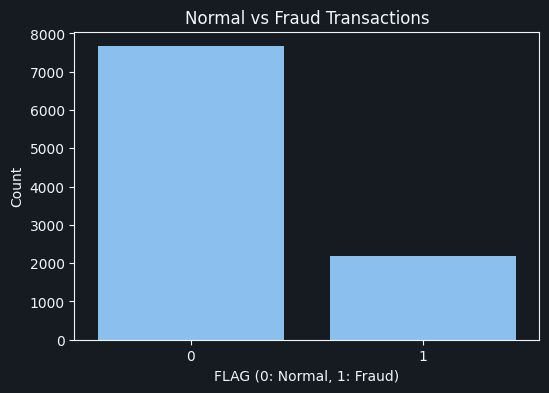

FLAG
0    77.857941
1    22.142059
Name: proportion, dtype: float64


In [145]:
df["FLAG"].value_counts()

plt.figure(figsize=(6, 4))
sns.countplot(x="FLAG", data=df)
plt.title("Normal vs Fraud Transactions")
plt.xlabel("FLAG (0: Normal, 1: Fraud)")
plt.ylabel("Count")
plt.show()

fraud_percentage = df["FLAG"].value_counts(normalize=True) * 100
print(fraud_percentage)


### Observation

The dataset is imbalanced, with significantly fewer fraud wallets compared to legitimate wallets.

In [146]:
correlation = df.corr(numeric_only=True)["FLAG"].sort_values(ascending=False)

print(correlation)

FLAG                                                    1.000000
ERC20_min_val_sent                                      0.025364
ERC20_avg_val_sent                                      0.025044
ERC20_max_val_sent                                      0.025038
ERC20_total_ether_sent                                  0.024762
ERC20_total_Ether_sent_contract                         0.013514
ERC20_min_val_rec                                       0.011163
ERC20_uniq_sent_token_name                              0.009249
ERC20_avg_val_rec                                       0.007881
min_val_sent                                            0.006626
ERC20_uniq_sent_addr.1                                 -0.003047
total_ether_balance                                    -0.003229
ERC20_max_val_rec                                      -0.004313
ERC20_total_Ether_received                             -0.004475
min_value_sent_to_contract                             -0.007213
max_val_sent_to_contract 

## Finding Features with the Highest Correlation to the Fraud Label `FLAG`:

In [147]:
best_features = correlation[1:11]

<Axes: title={'center': 'Top 10 Features Correlated with Fraud (FLAG)'}, xlabel='Correlation Coefficient', ylabel='Feature'>

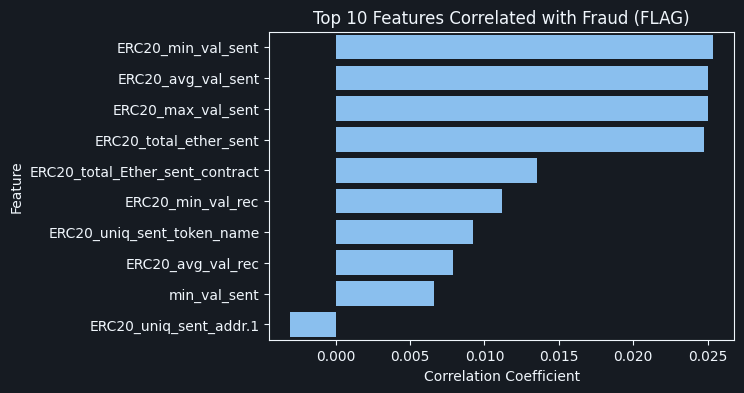

In [148]:
plt.figure(figsize=(6, 4))
plt.title("Top 10 Features Correlated with Fraud (FLAG)")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
sns.barplot(x = best_features.values, 
            y=best_features.index
)  

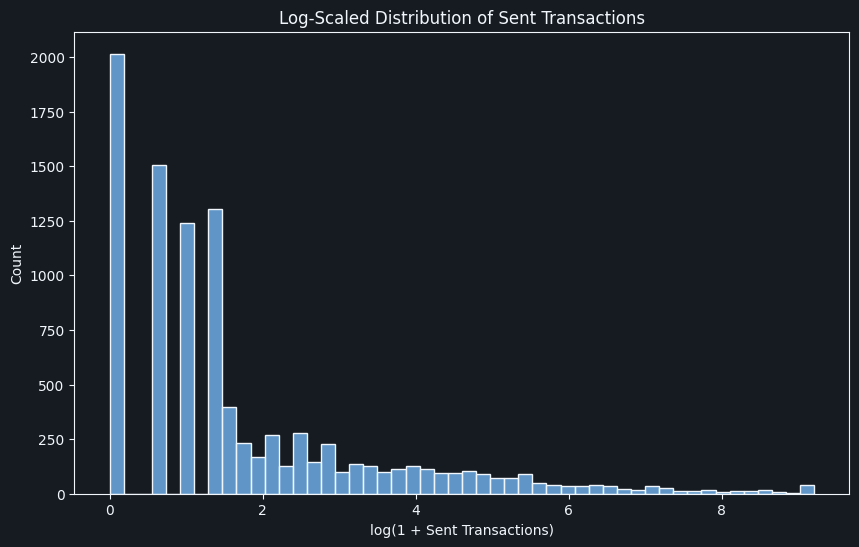

In [149]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(df["Sent_tnx"]),
    bins=50
)

plt.title("Log-Scaled Distribution of Sent Transactions")
plt.xlabel("log(1 + Sent Transactions)")
plt.ylabel("Count")

plt.show()

#### Observations:
- Most wallets exhibit relatively low transaction activity
- A small number of wallets are extremely active
- The dataset contains significant outliers
- Wallet activity is not normally distributed

## Behaviourial Analysis of Normal and Fraud Wallets:

Now, we investigate the behaviourial distributions between the normal and fraud wallets

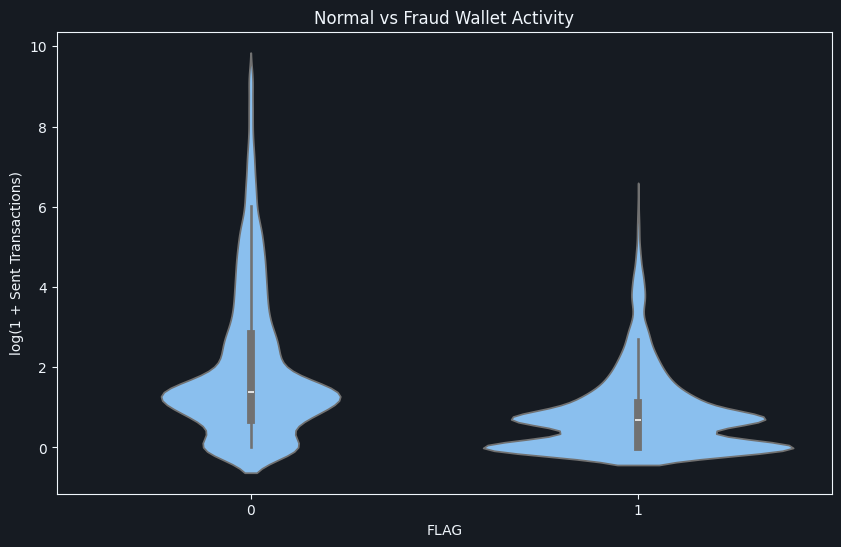

In [150]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x=df["FLAG"],
    y=np.log1p(df["Sent_tnx"])
)

plt.title("Normal vs Fraud Wallet Activity")
plt.xlabel("FLAG")
plt.ylabel("log(1 + Sent Transactions)")

plt.show()

### Observation

- Normal wallets generally exhibit higher transaction activity compared to fraud wallets.

- The fraud wallets are more concentrated around lower transaction counts, while normal wallets show a wider range of activity.

The top features correlated with Fraud Label `FLAG` are:
- ERC20 min val sent
- ERC20 avg val sent
- ERC20 max val sent
- ERC20 total ether sent


Most of them are related to ERC20 token transfer behavior, suggesting that token activity patterns may be more useful for fraud detection compared to single coin transactions/activity.

In [ ]:
important_features = [
    "ERC20 min_val_sent",
    "ERC20 avg_val_sent",
    "ERC20 max_val_sent",
    "ERC20 total_ether_sent"
]

Now, we create a function that visualizes the behaviour of the Fraud Label `FLAG` for a feature

In [152]:
def compare_feature(feature_name):

    plt.figure(figsize=(10,6))

    sns.violinplot(
        x=df["FLAG"],
        y=np.log1p(df[feature_name])
    )

    plt.title(f"Normal vs Fraud Wallet: {feature_name}")

    plt.xlabel("FLAG")
    plt.ylabel(f"log(1 + {feature_name})")

    plt.show()

### 1. ERC20_min_val_sent:

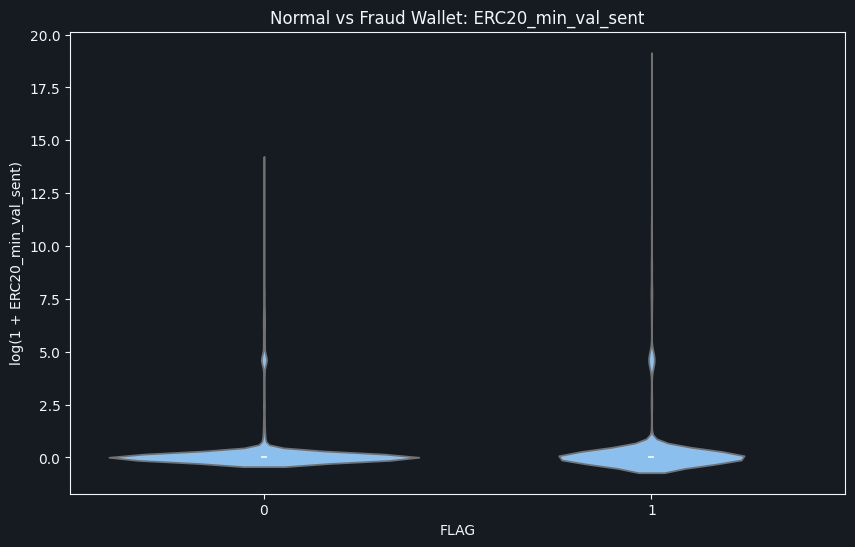

In [153]:
compare_feature("ERC20_min_val_sent")

### 2. ERC20_avg_val_sent:

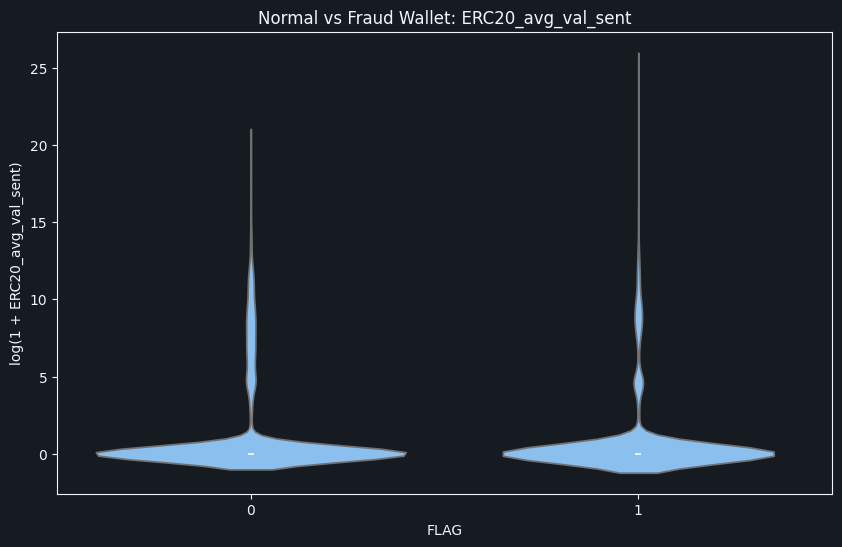

In [154]:
compare_feature("ERC20_avg_val_sent")

### 3. ERC20_max_val_sent:

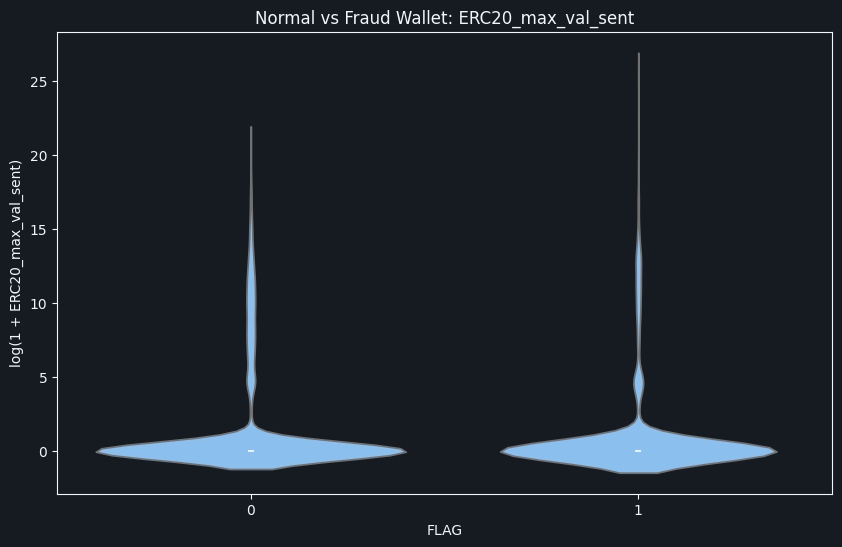

In [155]:
compare_feature("ERC20_max_val_sent")

### 4. ERC20_total_ether_sent:

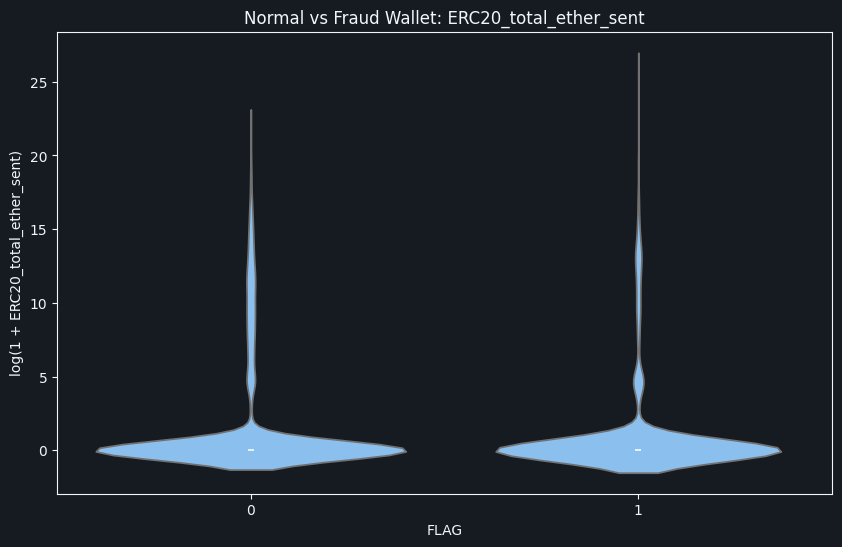

In [156]:
compare_feature("ERC20_total_ether_sent")

#### Normal Wallets (FLAG = 0) show:

- broader distributions
- greater variability
- more diverse transfer behavior

while:

#### Fraud Wallets (FLAG = 1) show:

- more concentrated distributions
- narrower behavioural spread
- stronger clustering near low values

### Observation — ERC20 Transfer Behaviour

The ERC20-related transfer features exhibit noticeable behavioral differences between fraudulent and legitimate wallets.

- Fraud wallets appear more concentrated around lower ERC20 transfer values and show narrower behavioural distributions overall.

- Normal wallets exhibit greater variability and broader transfer behaviour across average, maximum, and total ERC20 transfer metrics.

- This suggests that normal wallets show using more constrained or repetitive token transfer patterns, while normal wallets show more diverse transactional behaviour.

## Data Preprocessing:

In [157]:
print(df.shape)

(9841, 48)


#### Checking & Handling Missing Values:

In [158]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)



ERC20_most_sent_token_type             2697
ERC20_most_rec_token_type               871
ERC20_total_ether_sent                  829
ERC20_total_Ether_received              829
ERC20_uniq_sent_addr                    829
ERC20_uniq_rec_addr                     829
ERC20_uniq_sent_addr.1                  829
ERC20_total_Ether_sent_contract         829
Total_ERC20_tnxs                        829
ERC20_avg_time_between_sent_tnx         829
ERC20_uniq_rec_contract_addr            829
ERC20_avg_time_between_rec_tnx          829
ERC20_avg_time_between_rec_2_tnx        829
ERC20_max_val_rec                       829
ERC20_avg_val_rec                       829
ERC20_avg_time_between_contract_tnx     829
ERC20_min_val_rec                       829
ERC20_max_val_sent                      829
ERC20_min_val_sent                      829
ERC20_avg_val_sent                      829
ERC20_min_val_sent_contract             829
ERC20_avg_val_sent_contract             829
ERC20_max_val_sent_contract     

We will use median value of each feature to replace the missing numerical values.

In [159]:
cols = df.select_dtypes(include = np.number).columns

for col in cols:
    df[col] = df[col].fillna(df[col].median())

#### Converting Categorical Features into Numbers using Label Encoding:

In [160]:
categorical_cols = df.select_dtypes(include = "object").columns

categorical_cols

C:\Users\Avnish\AppData\Local\Temp\ipykernel_41264\2855299315.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include = "object").columns


Index(['ERC20_most_sent_token_type', 'ERC20_most_rec_token_type'], dtype='str')

In [161]:
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [162]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 48 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   FLAG                                                  9841 non-null   int64  
 1   Avg_min_between_sent_tnx                              9841 non-null   float64
 2   Avg_min_between_received_tnx                          9841 non-null   float64
 3   Time_Diff_between_first_and_last_(Mins)               9841 non-null   float64
 4   Sent_tnx                                              9841 non-null   int64  
 5   Received_Tnx                                          9841 non-null   int64  
 6   Number_of_Created_Contracts                           9841 non-null   int64  
 7   Unique_Received_From_Addresses                        9841 non-null   int64  
 8   Unique_Sent_To_Addresses                              9841 non-null  

#### Separating Data into Features and Labels:
- X - input features
- y - target labels

In [163]:
X = df.drop(columns=["FLAG"])

y = df["FLAG"]

#### Feature Scaling:
Used because:
- Transaction values vary enormously
- Data contains extreme outliers
- Some features use vastly different scales


In [164]:
sc = StandardScaler()

X_scaled = sc.fit_transform(X)

#### Train-Test Split: (80-20)

In [165]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=18, stratify=y
)

In [166]:
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (7872, 47)
Testing Features Shape: (1969, 47)
Training Labels Shape: (7872,)
Testing Labels Shape: (1969,)


## Baseline Machine Learning Models

#### Objective

After preprocessing the dataset, the next step is to train baseline machine learning models for Ethereum wallet fraud detection.

We will do the following tasks:

- establish baseline fraud classification performance using Logistic Regression model 
- evaluate model effectiveness for Logistic Regression, Random Forest and XGBoost
- analyze fraud detection capability for each model
- compare model behaviour

The first model selected is Logistic Regression because it is simple, interpretable, and widely used for binary classification problems.

In [167]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

## 1. Logistic Regression:

In [168]:
lr = LogisticRegression(random_state=18,
                        max_iter=1000)

In [169]:
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",18
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [170]:
lr_preds = lr.predict(X_test)

#### Accuracy, Precision, Recall & F1 Score for Logistic Regression:

Particular attention is given to Recall, since failing to detect fraud wallets is costly in real-world fraud detection systems.

In [171]:
lr_accuracy = accuracy_score(y_test, lr_preds)
lr_precision = precision_score(y_test, lr_preds)
lr_recall = recall_score(y_test, lr_preds)
lr_f1score = f1_score(y_test, lr_preds)

In [172]:
print("Logistic Regression Performance:")

print(f"Accuracy: {lr_accuracy}")
print(f"Precision: {lr_precision}")
print(f"Recall: {lr_recall}")
print(f"F1-Score: {lr_f1score}")

Logistic Regression Performance:
Accuracy: 0.9334687658710005
Precision: 0.8657074340527577
Recall: 0.8279816513761468
F1-Score: 0.8464243845252052


#### Classification Report for Logistic Regression:

In [173]:
print(classification_report(y_test, lr_preds))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1533
           1       0.87      0.83      0.85       436

    accuracy                           0.93      1969
   macro avg       0.91      0.90      0.90      1969
weighted avg       0.93      0.93      0.93      1969



#### Confusion Matrix for Logistic Regression:

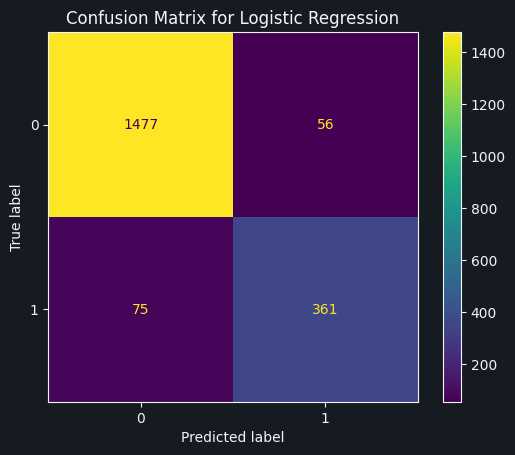

In [174]:
conf_mtrx_lr = confusion_matrix(y_test, lr_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_mtrx_lr, display_labels=lr.classes_)
disp.plot()

plt.title("Confusion Matrix for Logistic Regression")
plt.show()

#### ROC-AUC Score for Logistic Regression:

In [175]:
lr_probs = lr.predict_proba(X_test)[:, 1]

In [176]:
lr_roc_auc = roc_auc_score(y_test, lr_probs)

print(f"ROC-AUC Score for Logistic Regression: {lr_roc_auc}")

ROC-AUC Score for Logistic Regression: 0.9405973775711114


## 2. Random Forest:

In [177]:
from sklearn.ensemble import RandomForestClassifier

In [178]:
rf = RandomForestClassifier(random_state=18, 
                            n_estimators=100,
                            class_weight="balanced")

In [179]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [180]:
rf_preds = rf.predict(X_test)

#### Accuracy, Precision, Recall & F1-Score for Random Forest:

Particular attention is given to Recall, since failing to detect fraud wallets is costly in real-world fraud detection systems.

In [181]:
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds)
rf_recall = recall_score(y_test, rf_preds)
rf_f1score = f1_score(y_test, rf_preds)

In [182]:
print("Random Forest Performance:")

print(f"Accuracy: {rf_accuracy}")
print(f"Precision: {rf_precision}")
print(f"Recall: {rf_recall}")
print(f"F1-Score: {rf_f1score}")

Random Forest Performance:
Accuracy: 0.9903504316912138
Precision: 1.0
Recall: 0.9564220183486238
F1-Score: 0.977725674091442


#### Classification Report for Random Forest:

In [198]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1533
           1       1.00      0.96      0.98       436

    accuracy                           0.99      1969
   macro avg       0.99      0.98      0.99      1969
weighted avg       0.99      0.99      0.99      1969



#### Confusion Matrix for Random Forest:

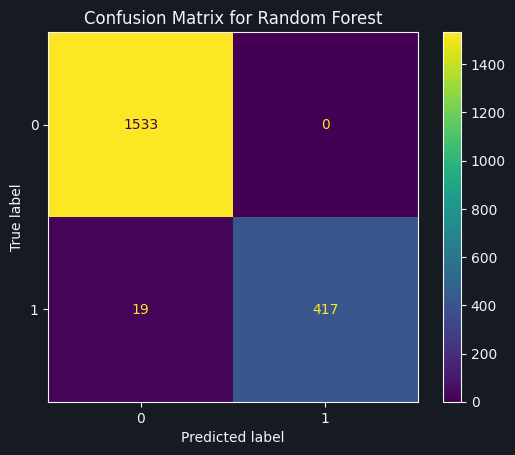

In [184]:
rf_conf_matrix = confusion_matrix(y_test, rf_preds)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=rf_conf_matrix, display_labels=rf.classes_)
disp_rf.plot()

plt.title("Confusion Matrix for Random Forest")
plt.show()

### ROC-AUC Score for Random Forest:

In [185]:
rf_probs = rf.predict_proba(X_test)[:,1]

In [186]:
rf_roc_auc = roc_auc_score(y_test, rf_probs)

print(f"ROC-AUC Score for Random Forest: {rf_roc_auc}")

ROC-AUC Score for Random Forest: 0.9992182684309114


## XGBoost Classification
XGBoost improves prediction performance by sequentially correcting errors made by previous decision trees, allowing it to capture highly complex behavioral relationships in blockchain transaction data.

In [187]:
from xgboost import XGBClassifier

#### XGBoost Initialization

In [188]:
xgb = XGBClassifier(objective = 'binary:logistic',
                    eval_metric='logloss',
                    random_state=18,
)

In [189]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [190]:
xgb_preds = xgb.predict(X_test)

#### Accuracy, Precision, Recall & F1-Score for XGBoost:

Particular attention is given to Recall, since failing to detect fraud wallets is costly in real-world fraud detection systems.

In [191]:
xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds)
xgb_recall = recall_score(y_test, xgb_preds)
xgb_f1score = f1_score(y_test, xgb_preds)

In [192]:
print("XGBoost Performance:")

print(f"Accuracy: {xgb_accuracy}")
print(f"Precision: {xgb_precision}")
print(f"Recall: {xgb_recall}")
print(f"F1-Score: {xgb_f1score}")

XGBoost Performance:
Accuracy: 0.9964448958862366
Precision: 1.0
Recall: 0.9839449541284404
F1-Score: 0.991907514450867


#### Classification Report for XGBoost:

In [193]:
print(classification_report(y_test, xgb_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1533
           1       1.00      0.98      0.99       436

    accuracy                           1.00      1969
   macro avg       1.00      0.99      0.99      1969
weighted avg       1.00      1.00      1.00      1969



#### Confusion Matrix for XGBoost:

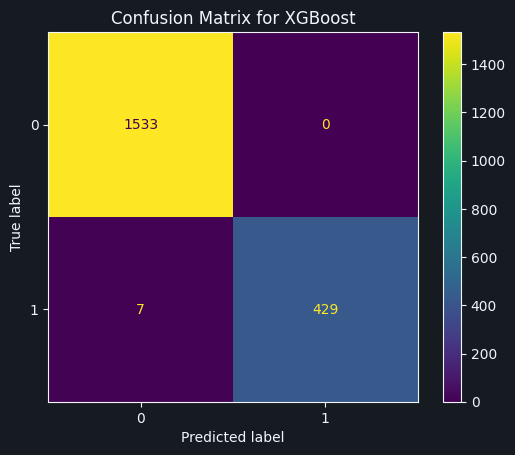

In [194]:
xgb_conf_matrix = confusion_matrix(y_test, xgb_preds)

xgb_disp = ConfusionMatrixDisplay(confusion_matrix=xgb_conf_matrix, display_labels=xgb.classes_)
xgb_disp.plot()

plt.title("Confusion Matrix for XGBoost")
plt.show()

#### ROC-AUC Score for XGBoost:

In [195]:
xgb_roc_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])

print(f"ROC-AUC Score for XGBoost: {xgb_roc_auc}")

ROC-AUC Score for XGBoost: 0.9986145771617683


#### Feature Importance Scores (XGBoost):

XGBoost provides feature importance scores, which helps us compare with Random Forest and our EDA findings

In [196]:
xgb_feature_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

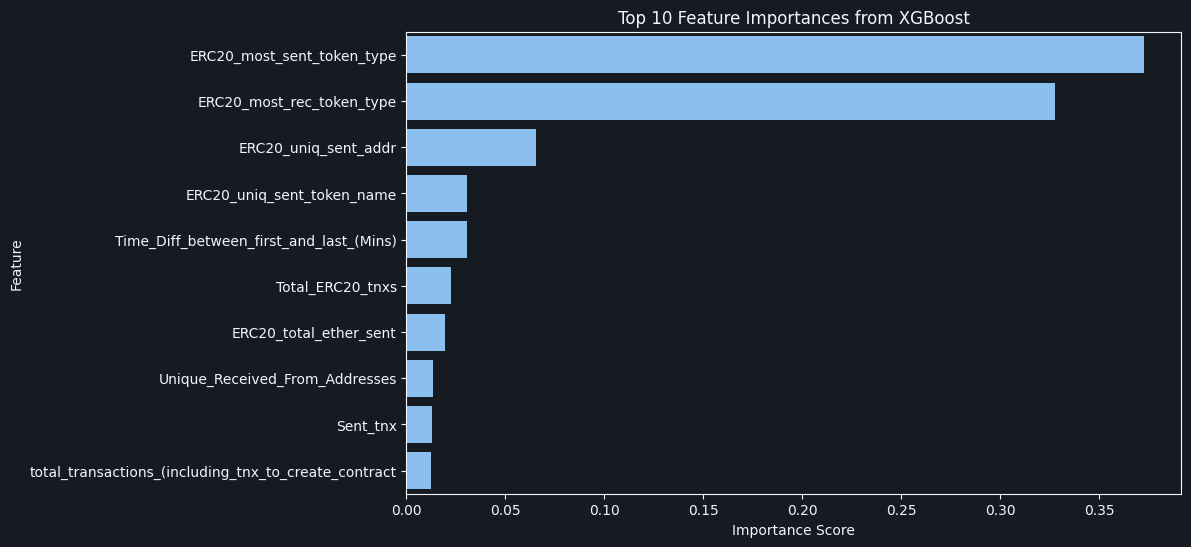

In [197]:
plt.figure(figsize=(10,6))

sns.barplot(
    data = xgb_feature_imp.head(10),
    x = "Importance",
    y = "Feature"
)

plt.title("Top 10 Feature Importances from XGBoost")

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

#### XGBoost Feature Importance Analysis:

Features:
- `ERC20_most_sent_token_type`
- `ERC20_most_rec_token_type`

were significantly more important than other features.

This suggests that certain token ecosystems may be closely associated with phishing activity, scam wallets, or suspicious transfer patterns.

Unlike the earlier correlation analysis, XGBoost captured deeper non-linear relationships and feature interactions between wallet behavior and token activity.

This indicates that Ethereum fraud detection depends not only on how much a wallet transacts, but also on the types of tokens and interaction patterns involved.

In [199]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        lr_precision,
        rf_precision,
        xgb_precision
    ],

    "Recall": [
        lr_recall,
        rf_recall,
        xgb_recall
    ],

    "F1 Score": [
        lr_f1score,
        rf_f1score,
        xgb_f1score
    ],

    "ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.933469,0.865707,0.827982,0.846424,0.940597
1,Random Forest,0.990350,1.000000,0.956422,0.977726,0.999218
2,XGBoost,0.996445,1.000000,0.983945,0.991908,0.998615


# Final Conclusion

This project explored Ethereum wallet fraud detection using machine learning.

The workflow included:

- exploratory data analysis (EDA)
- behavioral visualization
- data preprocessing
- Logistic Regression
- Random Forest
- XGBoost
- feature importance analysis

The results showed that ERC20 transaction behavior and token interaction patterns contain highly predictive fraud-related signals.

Among the evaluated models:
- Logistic Regression established a strong base model
- Random Forest significantly improved fraud detection rates
- XGBoost achieved the best overall performance with near perfect recall (~98.39%)

The project also demonstrated that non-linear models are highly effective for blockchain fraud detection tasks involving complex wallet behavior patterns.